# Squares by morphing a rigid 16-gon — one knob, and a control arm

**One knob (`morph`), shapes that cannot fold, two exact decimations, and no new library code.**

`setShapeTemplate(morph, sides = 4)` interpolates each polygon between its regular n-gon (`morph = 0`)
and a square (`morph = 1`), writing the edge **and** diagonal targets that pin it. With
`setConstraints(area = True, edge = True, diagonal = True)` the shape is fixed up to rigid motion, so
a polygon **cannot fold** — the failure that dogged the alternating-pairs protocol is removed by
construction rather than policed.

At `morph = 1` a 16-gon *is* a square carrying 12 collinear extras, so the **existing**
`halveNumEdges()` flat test removes them exactly: 16 → 8 → 4, no new decimation code, no masks, no
parity, no jitter.

## Why this, and why now

The alternating-pairs protocol worked mechanically but lost ground as it ran: side **2.7003** at
round 0 → 2.9260 → 2.9449, phi 0.686 → 0.577. The best number in that run was the *seed*, 0.26% off
the PROVED optimum of 2.70710678 for N = 5, before any compliance had been spent. So the real question
is not "which morph protocol" but **does shape compliance buy anything at all** — which is why this
notebook ends with a control arm.

## Three things that decide whether this works, all measured

**1. The over-determined set is consistent.** 16 edge + 16 diagonal + 1 area = **33 rows**, and the
block Jacobian has **rank 29 per polygon = exactly `2n - 3`**. The template derives edges and diagonals
from one closed polygon and matches the area by scaling, so the four surplus rows are dependent and
the truncated SVD drops them. The recorded 8.159e-01 failure of this same set was
`tests/squishyStiffen.py` `jumpProtocol`, which applies it in **one jump** from a far configuration.
Here the seed satisfies `morph = 1` already: `max|C| = 7.7e-12` on arrival.

**2. No jitter.** Edge + diagonal fix the shape only up to **reflection**, so perturbing off the
manifold invites a branch flip. Measured over the same ramp: no jitter → `max|C| = 9.0e-05`,
`|turn| = 360.001`; jitter 1e-3 → `max|C| = 8.6e-01`, `|turn| = 780` (folded). This is the opposite of
what the pairs protocol needed, and the reason is that this constraint set is *rigid*.

**3. `diagonal` comes OFF before the decimations.** A collinear vertex is exactly where the diagonal
row sits at its bound `d = a + b` **and** where the two reflection branches meet. Re-projecting onto
the template at n = 8 from there flipped a polygon inside out: `max|C| = 2.07`, `|turn| = 865`, 56% of
the area gone. With `setConstraints(area = True, edge = True)` before halving, the same chain is
exact:

| | dArea | max&#124;C&#124; | &#124;turn&#124; | &#124;corner − 90&#124; | kappa |
|---|---|---|---|---|---|
| free-space 16 → 8 → 4 | **1.8e-15** | 2.0e-15 | 360.0000 | **0.000000 deg** | 4.000000 |

## Also carried over from the pairs work

`placeOnGrid()` before anything relaxes. The depth contact law is non-monotonic past half overlap —
energy peaks near half (1.23e-04) and falls to 4.07e-06 at full stacking — so a stacked pair is a
genuine minimum and the build's random centres start on the wrong side of it. Measured: random centres
took `holdExcessEnergy` to phi 1.2963; from the grid it settles sanely.

In [1]:
import time

import numpy as np
from matplotlib import pyplot as plt

import pyPolygon as pp
import records

## 1. Seed: squares, doubled, on a lattice

n = 4 is the only count where the target set has a unique solution, so the build lands on real squares
(turns 89.88–90.12) instead of the folded stars it returns at every higher count — measured
`|turn|` 468/719/1089 deg at n = 8/16/32 against 360 for a simple polygon. `doubleNumEdges(2)` then
gives convex 16-gons with collinear extras, which is `morph = 1` exactly.

In [2]:
N = 5
n = 16
kappa = 4.0
phi0 = 0.45                   # low enough to fit the lattice; holdExcessEnergy compresses from here
openMorph = 0.35              # how far the shape is opened before closing back to a square
rampRounds = 24               # sub-steps EACH WAY. The only transient is the first step off morph 1
excess = 5e-5                 # how far above jamming to sit, on POLYGON-POLYGON contact alone
wallStiffness = 100.0
coarseness = 1e3
patience = 1000

print(records.describe(N))
bestKnown = records.bestKnownSide(N)
maxSquarePhi = records.maximumDensity(N)
print(f"densest possible for {N} squares: phi = {maxSquarePhi:.4f}")

packing = pp.Model(N = N, n = 4, seed = 42)
packing.generateEquilateralPolygons(phi = phi0, kappa = kappa)
packing.syncTargetAreas()
packing.doubleNumEdges(int(np.log2(n // 4)))
packing.placeOnGrid()
# NO JITTER -- see point 2. This set is rigid up to reflection, so noise invites a branch flip.

packing.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")
packing.setDepthContact(stiffness = 1.0, wallStiffness = wallStiffness)

asked, ceiling = packing.checkDensityFeasible()
print(f"area targets ask for phi {asked:.4f} against a ceiling of {ceiling:.4f}")

def count():
    return int(np.diff(packing.packing.startIndices)[0])

def side():
    """Container side if every polygon were rescaled to unit area -- comparable to bestKnown."""
    return float(np.sqrt(N / packing.getPackingFraction()))

def outside():
    r = packing.packing.positions.reshape(-1, 2)[:packing.packing.startIndices[N]]
    return int(((r < 0.0) | (r > 1.0)).any(axis = 1).sum())

def turns(polygon):
    starts = np.asarray(packing.packing.startIndices, dtype = int)
    loop = packing.packing.positions.reshape(-1, 2)[starts[polygon]:starts[polygon + 1]]
    behind = loop - np.roll(loop, 1, axis = 0)
    ahead = np.roll(loop, -1, axis = 0) - loop
    return np.degrees(np.arctan2(np.cross(behind, ahead),
                                 np.einsum("ij,ij->i", behind, ahead)))

def folded():
    """Worst total |turning angle|; exactly 360 for a simple polygon. The fold guard."""
    return max(float(np.abs(turns(p)).sum()) for p in range(N))

def corners():
    """Worst |turn - 90| in degrees; meaningful once the shapes are quadrilaterals."""
    return max(float(np.max(np.abs(np.abs(turns(p)) - 90.0))) for p in range(N))

def drift():
    """max|C| -- ShapeConstraints.projectPositions gives up SILENTLY at maxIter, so read it."""
    return float(packing.constraints.maxResidual(packing.packing))

print(f"seed: n = {count()}   |turn| {folded():.4f} deg   "
      f"pair overlap {packing.getPairOverlapArea():.6f}")

n = 5: PROVED optimum is side 2.70710678 = 2 + 1/2 sqrt(2)
densest possible for 5 squares: phi = 0.6823


/tmp/ipykernel_70254/1949626224.py:21: UserWarning: 
*** the polygons overhang a 3 x 2 lattice ***
    the widest spans 0.4243 against a cell of 0.3333, so neighbouring cells will overlap a little. That is usually harmless -- only a pair more than HALFWAY through each other is trapped -- but check getPairOverlapArea() before minimizing, and start at a lower packing fraction if it is a large fraction of a polygon's area.
  packing.placeOnGrid()


area targets ask for phi 0.4500 against a ceiling of 0.6823
seed: n = 16   |turn| 360.0000 deg   pair overlap 0.004506


## 2. The template goes on with zero jump

The seed already *is* `morph = 1`, so applying the template and the constraint set moves nothing. The
rank check is the one to watch: `2n - 3 = 29` on 33 rows means the surplus rows are dependent, not
contradictory.

block Jacobian (5, 33, 32)   rank per polygon [29 29 29 29 29]   (2n - 3 = 29)
max|C| on arrival 7.738e-12   |turn| 360.0022   kappa [4. 4. 4. 4. 4.]


FIRE (constrained):  40%|▊ | 4000/10000 [00:30<00:51, 117.32it/s, maxF=3.94e-06]/home/rdennis/Documents/Code/pyPolygon/model.py:3075: UserWarning: 
*** FIRE stopped at max|F| = 3.85e-06, converging at 0.12 decades per 1000 steps. Reaching the requested 1.0e-07 needs roughly 13,190 more steps, which this run's remaining budget does not cover; raise maxSteps if that is worth it, or relax the tolerance.

  energy, steps, _ = minimize.minimizeFIRE(
FIRE (constrained):  40%|▊ | 4000/10000 [00:30<00:45, 133.15it/s, maxF=3.94e-06]


  hold     phi 0.449999  excess 1.9965e-08  (target 5.0000e-05)  pairOverlap 5.887e-06
  hold     phi 0.472499  excess 4.9600e-07  (target 5.0000e-05)  pairOverlap 3.200e-05
  hold     phi 0.496124  excess 2.3170e-07  (target 5.0000e-05)  pairOverlap 1.314e-04
  hold     phi 0.520930  excess 2.3944e-07  (target 5.0000e-05)  pairOverlap 1.318e-04
  hold     phi 0.546977  excess 4.1842e-07  (target 5.0000e-05)  pairOverlap 1.789e-04
  hold     phi 0.574325  excess 3.7687e-04  (target 5.0000e-05)  pairOverlap 5.105e-03
  hold     phi 0.560484  excess 7.2562e-06  (target 5.0000e-05)  pairOverlap 1.326e-03
  hold     phi 0.567205  excess 9.3487e-05  (target 5.0000e-05)  pairOverlap 3.154e-03
  hold     phi 0.565552  excess 5.9618e-05  (target 5.0000e-05)  pairOverlap 2.705e-03
  hold     phi 0.564907  excess 4.8879e-05  (target 5.0000e-05)  pairOverlap 2.529e-03

seeded and jammed: phi 0.56491  side 2.9751  max|C| 2.11e-15  |turn| 360.000  overlap 2.53e-03  10 out


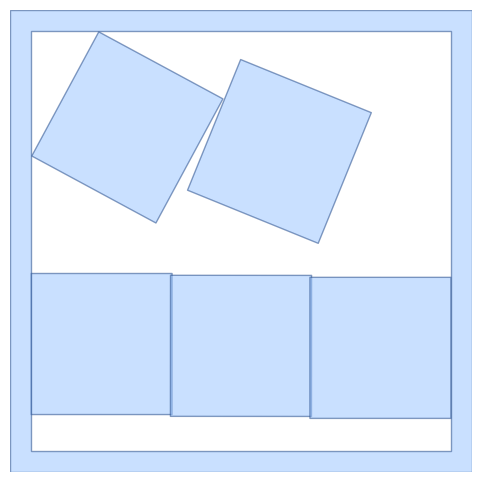

In [3]:
packing.setShapeTemplate(morph = 1.0, sides = 4)
packing.setConstraints(area = True, edge = True, diagonal = True)

J = np.asarray(packing.constraints.jacobian(packing.packing))
singular = np.linalg.svd(J, compute_uv = False)
rank = (singular > 1e-10 * singular.max()).sum(axis = 1)
print(f"block Jacobian {J.shape}   rank per polygon {rank}   (2n - 3 = {2 * count() - 3})")
print(f"max|C| on arrival {drift():.3e}   |turn| {folded():.4f}   "
      f"kappa {np.array2string(packing.getShapeIndices()[:N], precision = 6)}")

packing.minimizeFIRE(maxUnbalancedForce = 1e-7, maxSteps = 10000, patience = patience,
                     progressBar = "text")
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 4000, coarseness = coarseness,
                          patience = patience)
got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", verbose = True)
print(f"\nseeded and jammed: phi {phi:.5f}  side {side():.4f}  max|C| {drift():.2e}  "
      f"|turn| {folded():.3f}  overlap {packing.getPairOverlapArea():.2e}  {outside()} out")
packing.draw()
plt.show()

## 3. The ramp: open the shape, then close it

`morph` walks **1 → openMorph → 1**. Opening rounds the corners; it does **not** move them, because
the template's turning angles are indexed by vertex — so the away-and-back that wrecked the pairs
protocol's corner ramp does not apply here.

Every round: write the template, SHAKE onto it, relax the packing, correct the density. `max|C|`,
`|turn|` and the pair overlap are logged because each one caught a real failure in the previous
protocol, and none of `max|F|`, kappa or the targets notice when the state has gone wrong.

    0/48  morph 1.0000  kappa 4.00000  max|C| 2.9e-15  |turn|  360.000  lap 1.2e-03  phi 0.57460  side 2.9499  max|F| 7.8e-09  11 out
    1/48  morph 0.9729  kappa 3.97395  max|C| 2.2e-15  |turn|  360.000  lap 1.2e-03  phi 0.57914  side 2.9383  max|F| 4.7e-09  9 out
    2/48  morph 0.9458  kappa 3.94896  max|C| 2.9e-15  |turn|  360.000  lap 1.3e-03  phi 0.58195  side 2.9312  max|F| 8.4e-09  8 out
    3/48  morph 0.9187  kappa 3.92500  max|C| 3.4e-15  |turn|  360.000  lap 1.1e-03  phi 0.60687  side 2.8704  max|F| 7.8e-09  9 out
    4/48  morph 0.8917  kappa 3.90203  max|C| 2.2e-15  |turn|  360.000  lap 1.2e-03  phi 0.60938  side 2.8645  max|F| 9.7e-09  9 out
    5/48  morph 0.8646  kappa 3.88003  max|C| 4.7e-15  |turn|  360.000  lap 1.2e-03  phi 0.61155  side 2.8594  max|F| 9.4e-09  9 out
    6/48  morph 0.8375  kappa 3.85895  max|C| 2.2e-15  |turn|  360.000  lap 1.2e-03  phi 0.61359  side 2.8546  max|F| 9.3e-09  9 out
    7/48  morph 0.8104  kappa 3.83878  max|C| 2.0e-15  |turn|  360.0

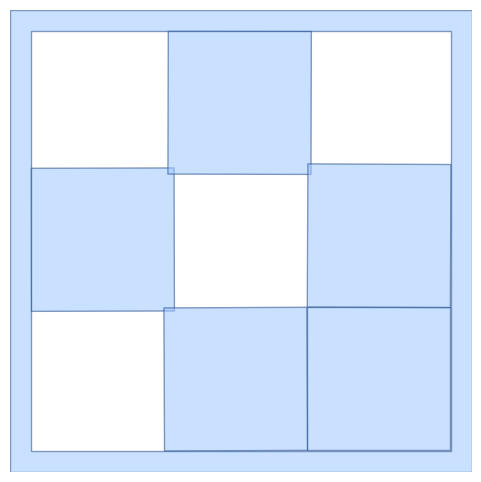

In [4]:
history = []
start = time.time()
for step in range(2 * rampRounds + 1):
    t = step / rampRounds
    morph = (1.0 - (1.0 - openMorph) * t) if t <= 1.0 else (openMorph + (1.0 - openMorph) * (t - 1.0))
    packing.setShapeTemplate(morph = morph, sides = 4)
    packing.constraints.projectPositions(packing.packing)
    packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 1500,
                              coarseness = coarseness, patience = patience)
    got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", maxRounds = 12,
                                        maxSteps = 1500)
    history.append(dict(morph = morph, phi = phi, side = side(), drift = drift(),
                        folded = folded(), overlap = packing.getPairOverlapArea(),
                        kappa = float(packing.getShapeIndices()[0]),
                        force = packing.getMaxUnbalancedForce(), outside = outside()))
    h = history[-1]
    print(f"  {step:3d}/{2 * rampRounds}  morph {h['morph']:.4f}  kappa {h['kappa']:.5f}  "
          f"max|C| {h['drift']:.1e}  |turn| {h['folded']:8.3f}  lap {h['overlap']:.1e}  "
          f"phi {h['phi']:.5f}  side {h['side']:.4f}  max|F| {h['force']:.1e}  "
          f"{h['outside']} out", flush = True)

print(f"\nramp took {time.time() - start:.1f} s")
packing.draw()
plt.show()

## 4. Decimate twice, then the endgame

**`diagonal` comes off first.** A collinear vertex is where the diagonal row sits at its bound and
where the two reflection branches meet, so re-projecting onto the template at the lower rungs flips
polygons inside out (measured `max|C| = 2.07`, 56% of the area gone). With `area + edge` only, both
halvings are exact, and at n = 4 that set forces the square on its own — an equilateral quadrilateral
with kappa 4 is a square and nothing else.

`setRegularTargets()` derives `P = 4 sqrt(A)` from each polygon's own area target so kappa lands
exactly on its floor rather than banking whatever the decimations cost.

In [ ]:
areaBefore = packing.getAreas()[:N].copy()
packing.setConstraints(area = True, edge = True)          # diagonal OFF -- see above
for rung in range(2):
    packing.halveNumEdges()
    print(f"  -> n = {count()}   dArea "
          f"{np.max(np.abs(packing.getAreas()[:N] / areaBefore - 1)):.2e}   "
          f"max|C| {drift():.2e}   |turn| {folded():.4f}")

packing.setRegularTargets()
packing.setConstraints(area = True, edge = True)
packing.minimizeFIRE(maxUnbalancedForce = 1e-7, maxSteps = 20000, patience = patience,
                     progressBar = "text")
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-10, maxSteps = 8000, coarseness = coarseness,
                          patience = patience)
got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", verbose = True)
packing.checkDensityFeasible()

morphSide = side()
print(f"\nMORPH ARM   phi {phi:.6f}   side {morphSide:.6f}   "
      f"worst |corner - 90| {corners():.6f} deg")
print(f"            kappa {np.array2string(packing.getShapeIndices()[:N], precision = 6)}")
print(f"            max|F| {packing.getMaxUnbalancedForce():.3e}   max|C| {drift():.2e}   "
      f"|turn| {folded():.4f}   {outside()} out")
if bestKnown is not None:
    print(f"            record {bestKnown:.6f}   ({100 * (morphSide / bestKnown - 1):+.3f}% off)")
packing.draw()
plt.show()

  -> n = 8   dArea 6.66e-16   max|C| 1.55e-15   |turn| 360.0000
  -> n = 4   dArea 8.88e-16   max|C| 6.66e-16   |turn| 360.0000


FIRE (constrained):   0%|                             | 0/20000 [00:00<?, ?it/s]


## 5. The control arm — does the compliance buy anything?

The same seed, the same density protocol, the same minimizers: **rigid squares from the first step**,
n = 4 throughout, no template, no ramp, no decimation. If this matches or beats the morph arm, the
whole cascade is machinery without a payoff, and that is worth knowing before building more of it.

Run it over several seeds before drawing a conclusion — one packing is one local minimum.

In [ ]:
def rigidArm(seed):
    """Rigid squares from the start: the no-compliance baseline."""
    control = pp.Model(N = N, n = 4, seed = seed)
    control.generateEquilateralPolygons(phi = phi0, kappa = kappa)
    control.syncTargetAreas()
    control.placeOnGrid()
    control.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))
    control.pinVertices(np.arange(control.getNumVertices())[-4:])
    control.setBoundaryConditions("fixed")
    control.setDepthContact(stiffness = 1.0, wallStiffness = wallStiffness)
    control.setConstraints(area = True, edge = True)
    control.minimizeFIRE(maxUnbalancedForce = 1e-7, maxSteps = 10000, patience = patience)
    control.minimizeFireLBFGS(maxUnbalancedForce = 1e-10, maxSteps = 8000,
                              coarseness = coarseness, patience = patience)
    control.holdExcessEnergy(excess, minimizer = "fireLbfgs")
    return float(np.sqrt(N / control.getPackingFraction())), control

controlSide, control = rigidArm(42)
print(f"rigid control (seed 42): side {controlSide:.6f}")
print(f"morph arm     (seed 42): side {morphSide:.6f}")
print(f"record                 : {bestKnown:.6f}")
print(f"\n-> compliance {'HELPED' if morphSide < controlSide else 'did NOT help'} on this seed "
      f"({100 * (morphSide / controlSide - 1):+.3f}%)")
control.draw()
plt.show()

In [ ]:
figure, axes = plt.subplots(1, 4, figsize = (19, 4))
x = np.arange(len(history))
for ax in axes:
    ax.set_xlabel("ramp round")
    ax.axvline(rampRounds, color = "0.7", linestyle = ":")     # the turnaround

axes[0].plot(x, [h["morph"] for h in history], marker = "o", label = "morph")
axes[0].plot(x, [h["kappa"] for h in history], marker = ".", label = "kappa")
axes[0].set_ylabel("shape"); axes[0].legend()

axes[1].semilogy(x, [max(h["drift"], 1e-16) for h in history], marker = "o", label = "max|C|")
axes[1].semilogy(x, [max(h["overlap"], 1e-16) for h in history], marker = ".", label = "pair overlap")
axes[1].set_ylabel("health (both should stay tiny)"); axes[1].legend()

axes[2].plot(x, [h["side"] for h in history], marker = "o", label = "side")
if bestKnown is not None:
    axes[2].axhline(bestKnown, linestyle = "--", color = "#c0392b", label = "record")
axes[2].set_ylabel("side (lower is better)"); axes[2].legend(); axes[2].invert_yaxis()

axes[3].plot(x, [h["folded"] for h in history], marker = "o")
axes[3].axhline(360.0, linestyle = "--", color = "0.5", label = "simple polygon")
axes[3].set_ylabel("|turn| sum (deg)"); axes[3].legend()
plt.tight_layout(); plt.show()